In [22]:
# ==============================================================================
# 🎯 MOTOR PREDITIVO: ESCANEAMENTO DAS 17:00 (INTEGRAÇÃO RELACIONAL NEONDB)
# ==============================================================================
import pandas as pd
from sqlalchemy import select
from datetime import date, timedelta
from database import AsyncSessionLocal
from models import ResultadoLoteria, BichoGrupoDezena  # Chamei nossa nova tabela aqui!

# 1. Puxa os dados atualizados com o relacionamento direto do banco
async with AsyncSessionLocal() as session:
    # 🐾 Adeus dicionário fixo! Buscamos a tabela de bichos viva do NeonDB
    bichos_query = await session.execute(select(BichoGrupoDezena))
    tabela_bichos_db = {b.grupo: b.bicho for b in bichos_query.scalars().all()}
    
    # 📊 Busca os resultados das loterias
    res = await session.execute(select(ResultadoLoteria))
    df = pd.DataFrame([item.__dict__ for item in res.scalars().all()])

# Tratamento e Higienização do DataFrame usando os dados dinâmicos do banco
df['data_hora'] = pd.to_datetime(df['data_hora'])
df['data_sorteio'] = df['data_hora'].dt.date

# 🔗 SACADA DE ENGENHARIA DE DADOS:
# Como a coluna 'grupo' já vem pronta do banco de dados, fazemos apenas o mapeamento direto!
# (Usamos um fallback de segurança caso existam dados antigos com grupo nulo)
if 'grupo' in df.columns:
    # Preenche nulos antigos se houver, convertendo a dezena na marra
    df['grupo'] = df['grupo'].fillna(
        df['resultado'].astype(str).str.zfill(2).str[-2:].apply(
            lambda d: 25 if int(d) == 0 else ((int(d) - 1) // 4) + 1 if d.isdigit() else None
        )
    )
else:
    # Se por acaso a coluna sumir, calcula dinamicamente
    df['grupo'] = df['resultado'].astype(str).str.zfill(2).str[-2:].apply(
        lambda d: 25 if int(d) == 0 else ((int(d) - 1) // 4) + 1 if d.isdigit() else None
    )

# Faz a tradução mágica usando o dicionário gerado pelo NeonDB
df['bicho'] = df['grupo'].map(tabela_bichos_db)

# Definição das variáveis de tempo
hoje_analise = date.today()
data_60_dias = hoje_analise - timedelta(days=60)

print(f"🔮 PROJEÇÃO ESTATÍSTICA: NACIONAL 17:00 (Matriz Atualizada via DB) 🔮")
print("=" * 80)

# FILTRO A: Memória Específica do Horário (Últimos 60 dias às 17:00)
df_17h_hist = df[(df['no_loteria'] == 'Nacional') & 
                 (df['horario'] == '17:00') & 
                 (df['data_sorteio'] >= data_60_dias)]
contagem_17h_hist = df_17h_hist['bicho'].value_counts()

print("⏳ 1. MEMÓRIA DO HORÁRIO (Donos históricos das 17:00 nos últimos 60 dias):")
for bicho, qtd in contagem_17h_hist.head(3).items():
    print(f"   • {bicho:<12} ➔ {qtd} aparições específicas neste horário")

# FILTRO B: Comportamento das últimas 24h pós-15:00
limite_24h = df['data_hora'].max() - pd.Timedelta(hours=24)
df_24h = df[(df['no_loteria'] == 'Nacional') & (df['data_hora'] >= limite_24h)]
contagem_24h = df_24h['bicho'].value_counts()

print("-" * 80)
print("⚡ 2. MOMENTUM RECENTE (O que mais saiu nas últimas 24h incluindo as 15:00):")
for bicho, qtd in contagem_24h.head(3).items():
    print(f"   • {bicho:<12} ➔ {qtd} aparições recentes")

print("=" * 80)
# FILTRO C: Cruzamento Inteligente (Chaves de Convergência)
bichos_chave = set(contagem_17h_hist.head(5).index).intersection(set(contagem_24h.head(5).index))
print("🎯 3. ANIMAIS DE CONVERGÊNCIA (União de Histórico das 17h + Força de Hoje):")
if bichos_chave:
    print(f"   🔥 ALVOS CRÍTICOS DETECTADOS: {', '.join(bichos_chave)}")
else:
    print("   ℹ️ Sem convergência direta. O algoritmo está alternando entre ciclos puros.")
print("=" * 80)

🔮 PROJEÇÃO ESTATÍSTICA: NACIONAL 17:00 (Matriz Atualizada via DB) 🔮
⏳ 1. MEMÓRIA DO HORÁRIO (Donos históricos das 17:00 nos últimos 60 dias):
   • PERU         ➔ 26 aparições específicas neste horário
   • BURRO        ➔ 25 aparições específicas neste horário
   • CAMELO       ➔ 24 aparições específicas neste horário
--------------------------------------------------------------------------------
⚡ 2. MOMENTUM RECENTE (O que mais saiu nas últimas 24h incluindo as 15:00):
   • PERU         ➔ 5 aparições recentes
   • CABRA        ➔ 5 aparições recentes
   • VEADO        ➔ 4 aparições recentes
🎯 3. ANIMAIS DE CONVERGÊNCIA (União de Histórico das 17h + Força de Hoje):
   🔥 ALVOS CRÍTICOS DETECTADOS: CABRA, TOURO, PERU


In [2]:
# ==============================================================================
# 🐾 ETAPA 1: TERMÔMETRO HORÁRIO MULTIJANELA (24H vs 48H vs 72H)
# ==============================================================================
import pandas as pd
from sqlalchemy import select
from datetime import date, timedelta
from database import AsyncSessionLocal
from models import ResultadoLoteria, BichoGrupoDezena

# ⚙️ PARAMETRIZAÇÃO DO ALVO (Altere o horário conforme o dia avança)
HORARIO_ALVO = '17:00'
LOTERIA_ALVO = 'Nacional'

# 1. Carga Relacional Limpa do NeonDB
async with AsyncSessionLocal() as session:
    bichos_query = await session.execute(select(BichoGrupoDezena))
    tabela_bichos_db = {b.grupo: b.bicho for b in bichos_query.scalars().all()}
    
    res = await session.execute(select(ResultadoLoteria))
    df_raw = pd.DataFrame([item.__dict__ for item in res.scalars().all()])

# 2. Preparação da Matriz
df_raw['data_hora'] = pd.to_datetime(df_raw['data_hora'])
df_raw['data_sorteio'] = df_raw['data_hora'].dt.date
df_raw['dezena'] = df_raw['resultado'].astype(str).str.zfill(2).str[-2:]
df_raw['grupo'] = df_raw['grupo'].fillna(
    df_raw['resultado'].astype(str).str.zfill(2).str[-2:].apply(
        lambda d: 25 if int(d) == 0 else ((int(d) - 1) // 4) + 1 if d.isdigit() else None
    )
)
df_raw['bicho'] = df_raw['grupo'].map(tabela_bichos_db)

# Filtra estritamente a loteria e o horário alvo para evitar ruídos de outros turnos
df_alvo = df_raw[(df_raw['no_loteria'] == LOTERIA_ALVO) & (df_raw['horario'] == HORARIO_ALVO)].copy()

# 3. Definição das Janelas Temporais Móveis
ultimo_sorteio = df_raw['data_hora'].max()
marcador_24h = ultimo_sorteio - pd.Timedelta(hours=24)
marcador_48h = ultimo_sorteio - pd.Timedelta(hours=48)
marcador_72h = ultimo_sorteio - pd.Timedelta(hours=72)

janelas = {
    "⚡ 24 HORAS MÓVEIS": df_alvo[df_alvo['data_hora'] >= marcador_24h],
    "🔄 48 HORAS MÓVEIS": df_alvo[df_alvo['data_hora'] >= marcador_48h],
    "⏳ 72 HORAS MÓVEIS": df_alvo[df_alvo['data_hora'] >= marcador_72h]
}

print(f"🌡️ RASTREADOR TÉRMICO RELACIONAL - HORÁRIO: {HORARIO_ALVO} ({LOTERIA_ALVO}) 🌡️")
print("=" * 80)

for nome_janela, df_janela in janelas.items():
    print(f"\n{nome_janela}")
    print("-" * 80)
    
    if df_janela.empty:
        print("   -> Sem registros suficientes nesta janela para o horário alvo.")
        continue
        
    contagem = df_janela['bicho'].value_counts()
    
    # Cortes matemáticos baseados na distribuição real da janela
    q_alta = contagem.quantile(0.65)
    q_baixa = contagem.quantile(0.35)
    
    quentes, mornos, frios = [], [], []
    
    for grupo_id, bicho_nome in tabela_bichos_db.items():
        qtd = contagem.get(bicho_nome, 0)
        item_str = f"{bicho_nome} (G-{str(grupo_id).zfill(2)}) [{qtd}x]"
        
        if qtd >= q_alta and qtd > 0:
            quentes.append(item_str)
        elif qtd > q_baixa:
            mornos.append(item_str)
        else:
            frios.append(item_str)
            
    print(f"   🔥 QUENTES (Aceleração): {', '.join(quentes[:5]) if quentes else 'Nenhum'}")
    print(f"   🫖 MORNOS     (Estáveis): {', '.join(mornos[:5]) if mornos else 'Nenhum'}")
    print(f"   ❄️ FRIOS     (Retidos) : {', '.join(frios[:5]) if frios else 'Nenhum'}")
print("=" * 80)

🌡️ RASTREADOR TÉRMICO RELACIONAL - HORÁRIO: 17:00 (Nacional) 🌡️

⚡ 24 HORAS MÓVEIS
--------------------------------------------------------------------------------
   🔥 QUENTES (Aceleração): AVESTRUZ (G-01) [1x], ÁGUIA (G-02) [1x], BURRO (G-03) [1x], GALO (G-13) [1x], PERU (G-20) [1x]
   🫖 MORNOS     (Estáveis): Nenhum
   ❄️ FRIOS     (Retidos) : BORBOLETA (G-04) [0x], CACHORRO (G-05) [0x], CABRA (G-06) [0x], CARNEIRO (G-07) [0x], CAMELO (G-08) [0x]

🔄 48 HORAS MÓVEIS
--------------------------------------------------------------------------------
   🔥 QUENTES (Aceleração): AVESTRUZ (G-01) [1x], ÁGUIA (G-02) [2x], BURRO (G-03) [1x], BORBOLETA (G-04) [1x], CABRA (G-06) [1x]
   🫖 MORNOS     (Estáveis): Nenhum
   ❄️ FRIOS     (Retidos) : CACHORRO (G-05) [0x], CARNEIRO (G-07) [0x], COBRA (G-09) [0x], CAVALO (G-11) [0x], ELEFANTE (G-12) [0x]

⏳ 72 HORAS MÓVEIS
--------------------------------------------------------------------------------
   🔥 QUENTES (Aceleração): AVESTRUZ (G-01) [1x], ÁG

In [3]:
# ==============================================================================
# 👥 ETAPA 2: RASTREADOR DE CASAIS (COOCORRÊNCIA EM SORTEIOS DAS 17:00)
# ==============================================================================
import pandas as pd
from sqlalchemy import select
from datetime import date, timedelta
from itertools import combinations  # Maquinário matemático para gerar os pares
from database import AsyncSessionLocal
from models import ResultadoLoteria, BichoGrupoDezena

HORARIO_ALVO = '17:00'
LOTERIA_ALVO = 'Nacional'

# 1. Puxa tabelas vivas do banco de dados
async with AsyncSessionLocal() as session:
    bichos_query = await session.execute(select(BichoGrupoDezena))
    tabela_bichos_db = {b.grupo: b.bicho for b in bichos_query.scalars().all()}
    
    res = await session.execute(select(ResultadoLoteria))
    df_raw = pd.DataFrame([item.__dict__ for item in res.scalars().all()])

# 2. Modelagem e Higienização dos dados na RAM
df_raw['data_hora'] = pd.to_datetime(df_raw['data_hora'])
df_raw['grupo'] = df_raw['grupo'].fillna(
    df_raw['resultado'].astype(str).str.zfill(2).str[-2:].apply(
        lambda d: 25 if int(d) == 0 else ((int(d) - 1) // 4) + 1 if d.isdigit() else None
    )
)
df_raw['bicho'] = df_raw['grupo'].map(tabela_bichos_db)

# Filtra estritamente a loteria e o horário alvo
df_alvo = df_raw[(df_raw['no_loteria'] == LOTERIA_ALVO) & (df_raw['horario'] == HORARIO_ALVO)].copy()

# 3. Marcadores Temporais Móveis
ultimo_sorteio = df_raw['data_hora'].max()
janelas = {
    "⚡ JANELA 24H MÓVEIS": df_alvo[df_alvo['data_hora'] >= (ultimo_sorteio - pd.Timedelta(hours=24))],
    "🔄 JANELA 48H MÓVEIS": df_alvo[df_alvo['data_hora'] >= (ultimo_sorteio - pd.Timedelta(hours=48))],
    "⏳ JANELA 72H MÓVEIS": df_alvo[df_alvo['data_hora'] >= (ultimo_sorteio - pd.Timedelta(hours=72))]
}

def calcular_frequencia_casais(df_janela):
    """Agrupa por sorteio e calcula quais pares saíram juntos no mesmo resultado"""
    # Agrupa por cada sorteio individual e gera um set de bichos únicos que saíram nele
    sorteios = df_janela.groupby('data_hora')['bicho'].apply(lambda x: list(set(x.dropna())))
    
    lista_pares = []
    for bichos in sorteios:
        if len(bichos) >= 2:
            # Ordena alfabeticamente para evitar que ('TIGRE', 'VEADO') e ('VEADO', 'TIGRE') fiquem separados
            for par in combinations(sorted(bichos), 2):
                lista_pares.append(par)
                
    if not lista_pares:
        return pd.Series(dtype=int)
    return pd.Series(lista_pares).value_counts()

print(f"👥 DETECTOR DE COOCORRÊNCIA DE CASAIS - HORÁRIO: {HORARIO_ALVO} 👥")
print("=" * 80)

for nome_janela, df_janela in janelas.items():
    print(f"\n{nome_janela}")
    print("-" * 80)
    
    contagem_casais = calcular_frequencia_casais(df_janela)
    
    if contagem_casais.empty:
        print("   -> Nenhum par de bicho se repetiu no mesmo sorteio nesta janela.")
        continue
        
    # Extrai os limites estatísticos para classificar a temperatura dos casais
    max_aparições = contagem_casais.max()
    
    quentes, mornos, frios = [], [], []
    
    for par, qtd in contagem_casais.items():
        par_formatado = f"• {par[0]} & {par[1]} ({qtd}x)"
        
        # Classificação baseada no teto de aparições da própria janela
        if max_aparições > 1:
            if qtd == max_aparições:
                quentes.append(par_formatado)
            elif qtd > 1:
                mornos.append(par_formatado)
            else:
                frios.append(par_formatado)
        else:
            # Se todos saíram apenas 1 vez, entram como mornos em observação
            mornos.append(par_formatado)
            
    print(f"   🔥 CASAIS QUENTES (Saindo grudados): {', '.join(quentes[:3]) if quentes else 'Nenhum par dominante ainda'}")
    print(f"   🫖 CASAIS MORNOS  (Frequência regular): {', '.join(mornos[:4]) if mornos else 'Nenhum'}")
    print(f"   ❄️ CASAIS FRIOS   (Saíram apenas 1x) : {len(frios)} pares listados na base")
print("=" * 80)

👥 DETECTOR DE COOCORRÊNCIA DE CASAIS - HORÁRIO: 17:00 👥

⚡ JANELA 24H MÓVEIS
--------------------------------------------------------------------------------
   🔥 CASAIS QUENTES (Saindo grudados): Nenhum par dominante ainda
   🫖 CASAIS MORNOS  (Frequência regular): • AVESTRUZ & BURRO (1x), • AVESTRUZ & GALO (1x), • AVESTRUZ & PERU (1x), • AVESTRUZ & TIGRE (1x)
   ❄️ CASAIS FRIOS   (Saíram apenas 1x) : 0 pares listados na base

🔄 JANELA 48H MÓVEIS
--------------------------------------------------------------------------------
   🔥 CASAIS QUENTES (Saindo grudados): Nenhum par dominante ainda
   🫖 CASAIS MORNOS  (Frequência regular): • BORBOLETA & CABRA (1x), • BORBOLETA & CAMELO (1x), • BORBOLETA & COELHO (1x), • BORBOLETA & MACACO (1x)
   ❄️ CASAIS FRIOS   (Saíram apenas 1x) : 0 pares listados na base

⏳ JANELA 72H MÓVEIS
--------------------------------------------------------------------------------
   🔥 CASAIS QUENTES (Saindo grudados): • BORBOLETA & MACACO (2x)
   🫖 CASAIS MORNOS  

In [4]:
# ==============================================================================
# 🔮 ETAPA 3: RASTREADOR DE MILHARES E CENTENAS (QUENTES, MORNOS E FRIOS)
# ==============================================================================
import pandas as pd
from sqlalchemy import select
from datetime import date, timedelta
from database import AsyncSessionLocal
from models import ResultadoLoteria, BichoGrupoDezena

HORARIO_ALVO = '23:00'
LOTERIA_ALVO = 'Nacional'

# 1. Puxa tabelas vivas do banco de dados NeonDB
async with AsyncSessionLocal() as session:
    bichos_query = await session.execute(select(BichoGrupoDezena))
    tabela_bichos_db = {b.grupo: b.bicho for b in bichos_query.scalars().all()}
    
    res = await session.execute(select(ResultadoLoteria))
    df_raw = pd.DataFrame([item.__dict__ for item in res.scalars().all()])

# 2. Modelagem e Higienização completa dos dados na RAM (Evita KeyError)
df_raw['data_hora'] = pd.to_datetime(df_raw['data_hora'])
df_raw['data_sorteio'] = df_raw['data_hora'].dt.date  # <--- Linha salvadora que corrige o erro!
df_raw['dezena'] = df_raw['resultado'].astype(str).str.zfill(2).str[-2:]
df_raw['grupo'] = df_raw['grupo'].fillna(
    df_raw['resultado'].astype(str).str.zfill(2).str[-2:].apply(
        lambda d: 25 if int(d) == 0 else ((int(d) - 1) // 4) + 1 if d.isdigit() else None
    )
)
df_raw['bicho'] = df_raw['grupo'].map(tabela_bichos_db)

# Filtra estritamente a loteria e o horário alvo para análise cirúrgica
df_alvo = df_raw[(df_raw['no_loteria'] == LOTERIA_ALVO) & (df_raw['horario'] == HORARIO_ALVO)].copy()

# Extrai os últimos 3 dígitos (Centenas) e os 4 dígitos (Milhares)
df_alvo['centena'] = df_alvo['resultado'].astype(str).str.zfill(4).str[-3:]
df_alvo['milhar'] = df_alvo['resultado'].astype(str).str.zfill(4)

# Definição das variáveis de tempo móveis (Evita NameError)
hoje_analise = date.today()
ultimo_sorteio = df_raw['data_hora'].max()
marcador_48h = ultimo_sorteio - pd.Timedelta(hours=48)

janelas_mils = {
    "⚡ RADAR ULTRA-CURTO (Últimas 48h às 17h)": df_alvo[df_alvo['data_hora'] >= marcador_48h],
    "⏳ MATRIZ MACRO (Últimos 30 dias às 17h)": df_alvo[df_alvo['data_sorteio'] >= (hoje_analise - timedelta(days=30))]
}

print(f"🔮 RASTREADOR DE MILHARES E CENTENAS - HORÁRIO: {HORARIO_ALVO} ({LOTERIA_ALVO}) 🔮")
print("=" * 80)

for nome_j, df_j in janelas_mils.items():
    print(f"\n{nome_j}")
    print("-" * 80)
    
    if df_j.empty:
        print("   -> Dados insuficientes para processar volumes de milhares nesta janela.")
        continue
        
    # Análise de Centenas (Terminações de 3 dígitos)
    contagem_cen = df_j['centena'].value_counts()
    
    # Padrão de Inicial de Milhar (Captura a tendência do primeiro dígito da banca)
    df_j['primeiro_digito'] = df_j['milhar'].str[0]
    contagem_digito = df_j['primeiro_digito'].value_counts()
    
    print("   🎯 CENTENAS (3 Dígitos) MAIS RECORRENTES:")
    for cen, qtd in list(contagem_cen.head(3).items()):
        # Calcula dinamicamente o bicho da centena baseado nos dois últimos dígitos dela
        dezena_cen = cen[-2:]
        grupo_cen = 25 if int(dezena_cen) == 0 else ((int(dezena_cen) - 1) // 4) + 1 if dezena_cen.isdigit() else None
        bicho_cen = tabela_bichos_db.get(grupo_cen, "Desconhecido")
        print(f"      • Centena [{cen}] ➔ {qtd}x (Pertence ao bicho: {bicho_cen})")
        
    print("\n   🎰 COMPORTAMENTO DO 1º DÍGITO (Milhar inicial):")
    quentes_d = [f"[{d}] ({q}x)" for d, q in list(contagem_digito.head(2).items())]
    frios_d = [f"[{d}] ({q}x)" for d, q in list(contagem_digito.tail(2).items())]
    print(f"      🔥 Inicial Quente: {', '.join(quentes_d)}")
    print(f"      ❄️ Inicial Frio  : {', '.join(frios_d)}")
print("=" * 80)

🔮 RASTREADOR DE MILHARES E CENTENAS - HORÁRIO: 23:00 (Nacional) 🔮

⚡ RADAR ULTRA-CURTO (Últimas 48h às 17h)
--------------------------------------------------------------------------------
   🎯 CENTENAS (3 Dígitos) MAIS RECORRENTES:
      • Centena [371] ➔ 1x (Pertence ao bicho: PORCO)
      • Centena [683] ➔ 1x (Pertence ao bicho: TOURO)
      • Centena [290] ➔ 1x (Pertence ao bicho: URSO)

   🎰 COMPORTAMENTO DO 1º DÍGITO (Milhar inicial):
      🔥 Inicial Quente: [4] (2x), [5] (2x)
      ❄️ Inicial Frio  : [6] (1x), [8] (1x)

⏳ MATRIZ MACRO (Últimos 30 dias às 17h)
--------------------------------------------------------------------------------
   🎯 CENTENAS (3 Dígitos) MAIS RECORRENTES:
      • Centena [902] ➔ 3x (Pertence ao bicho: AVESTRUZ)
      • Centena [274] ➔ 2x (Pertence ao bicho: PAVÃO)
      • Centena [528] ➔ 2x (Pertence ao bicho: CARNEIRO)

   🎰 COMPORTAMENTO DO 1º DÍGITO (Milhar inicial):
      🔥 Inicial Quente: [0] (49x), [1] (22x)
      ❄️ Inicial Frio  : [8] (15x), [2

In [43]:
# ==============================================================================
# 📊 INSPEÇÃO DE DADOS: ÚLTIMOS RESULTADOS - EXCLUSIVO LOTERIA NACIONAL
# ==============================================================================
import pandas as pd
from sqlalchemy import select
from database import AsyncSessionLocal
from models import ResultadoLoteria, BichoGrupoDezena

async with AsyncSessionLocal() as session:
    # 🐾 Carrega o mapeamento dinâmico direto do banco de dados
    bichos_query = await session.execute(select(BichoGrupoDezena))
    tabela_bichos_db = {b.grupo: b.bicho for b in bichos_query.scalars().all()}
    
    # 📥 Puxa a base completa de resultados
    res = await session.execute(select(ResultadoLoteria))
    df = pd.DataFrame([item.__dict__ for item in res.scalars().all()])

# Tratamento e Higienização Relacional na RAM
df['data_hora'] = pd.to_datetime(df['data_hora'])
df['data_sorteio'] = df['data_hora'].dt.date
df['dezena'] = df['resultado'].astype(str).str.zfill(2).str[-2:]
df['grupo'] = df['grupo'].fillna(
    df['resultado'].astype(str).str.zfill(2).str[-2:].apply(
        lambda d: 25 if int(d) == 0 else ((int(d) - 1) // 4) + 1 if d.isdigit() else None
    )
)
df['bicho'] = df['grupo'].map(tabela_bichos_db)

# 🎯 FILTRO DE ELITE: Isola estritamente a Loteria Nacional
df_nacional = df[df['no_loteria'] == 'Nacional']

# Ordena de forma decrescente pela data/hora e crescente pelo prêmio (1º ao 7º)
df_ultimos = df_nacional.sort_values(by=['data_hora', 'premio'], ascending=[False, True]).head(28)

print("🔍 INSPEÇÃO: ÚLTIMOS 28 PRÊMIOS DA LOTERIA NACIONAL NO NEONDB 🔍")
print("=" * 90)
if not df_ultimos.empty:
    display(df_ultimos[['data_sorteio', 'horario', 'no_loteria', 'premio', 'resultado', 'dezena', 'grupo', 'bicho']])
else:
    print("⚠️ Nenhhum registro da loteria 'Nacional' foi encontrado no banco de dados.")
print("=" * 90)

🔍 INSPEÇÃO: ÚLTIMOS 28 PRÊMIOS DA LOTERIA NACIONAL NO NEONDB 🔍


,data_sorteio,horario,no_loteria,premio,resultado,dezena,grupo,bicho
5796,2026-07-17,12:00,Nacional,1,1542,42,11,CAVALO
5797,2026-07-17,12:00,Nacional,2,0338,38,10,COELHO
5798,2026-07-17,12:00,Nacional,3,5587,87,22,TIGRE
5799,2026-07-17,12:00,Nacional,4,1067,67,17,MACACO
5800,2026-07-17,12:00,Nacional,5,1967,67,17,MACACO
5801,2026-07-17,12:00,Nacional,6,0501,01,1,AVESTRUZ
5802,2026-07-17,12:00,Nacional,7,0521,21,6,CABRA
5784,2026-07-17,10:00,Nacional,1,6431,31,8,CAMELO
5785,2026-07-17,10:00,Nacional,2,0495,95,24,VEADO
5786,2026-07-17,10:00,Nacional,3,7979,79,20,PERU


In [16]:
# ==============================================================================
# 🎯 ANÁLISE QUANTITATIVA: TERNOS DE DEZENA ÍMPARES POR JANELA DE TEMPO
# ==============================================================================
import pandas as pd
import itertools
from collections import Counter
from sqlalchemy import select
from database import AsyncSessionLocal
from models import ResultadoLoteria

async def analisar_ternos_impares_temporal():
    print("🔍 Conectando ao NeonDB e extraindo histórico...")
    async with AsyncSessionLocal() as session:
        res = await session.execute(select(ResultadoLoteria))
        df = pd.DataFrame([item.__dict__ for item in res.scalars().all()])
        
    if df.empty:
        print("⚠️ O banco de dados está vazio.")
        return

    # 1. Higienização Base
    df['data_hora'] = pd.to_datetime(df['data_hora'])
    df['dezena'] = df['resultado'].astype(str).str.zfill(2).str[-2:]
    
    # 2. Filtro de Dezenas Ímpares
    def is_impar(dezena_str):
        if dezena_str.isdigit():
            return int(dezena_str) % 2 != 0
        return False

    df_impar = df[df['dezena'].apply(is_impar)].copy()
    
    # Referência de tempo (o sorteio mais recente do banco)
    data_recente = df_impar['data_hora'].max()
    print(f"🕒 Data de referência do banco: {data_recente.strftime('%d/%m/%Y %H:%M')}")

    # 3. Definição das Janelas de Tempo
    janelas = {
        "Últimas 24 Horas": data_recente - pd.Timedelta(hours=24),
        "Últimas 48 Horas": data_recente - pd.Timedelta(hours=48),
        "Últimos 7 Dias": data_recente - pd.Timedelta(days=7),
        "Histórico Global": None
    }

    # Função interna para calcular e exibir o Top 5 de uma janela específica
    def calcular_top_ternos(df_janela, nome_janela, top_n=10):
        sorteios = df_janela.groupby(['no_loteria', 'data_hora'])['dezena'].unique()
        frequencia_ternos = Counter()

        for dezenas in sorteios:
            validas = [d for d in dezenas if d and d.isdigit()]
            if len(validas) >= 3:
                ternos = list(itertools.combinations(sorted(validas), 3))
                frequencia_ternos.update(ternos)

        top = frequencia_ternos.most_common(top_n)
        
        if not top:
            print(f"\n⚠️ Nenhum Terno Ímpar formado na janela: {nome_janela}")
            return

        dados_tabela = []
        for rank, (terno, qtd) in enumerate(top, 1):
            dados_tabela.append({
                "Ranking": f"{rank}º",
                "Terno Ímpar": f"{terno[0]} - {terno[1]} - {terno[2]}",
                "Frequência": qtd
            })
            
        df_ranking = pd.DataFrame(dados_tabela)
        print("\n" + "=" * 55)
        print(f" 🔥 TOP {top_n} TERNOS ÍMPARES: {nome_janela.upper()} 🔥")
        print("=" * 55)
        display(df_ranking.style.hide(axis="index"))

    # 4. Rodar o motor para cada janela de tempo
    for nome_janela, data_limite in janelas.items():
        if data_limite is not None:
            df_filtrado = df_impar[df_impar['data_hora'] >= data_limite]
        else:
            df_filtrado = df_impar # Histórico global
            
        calcular_top_ternos(df_filtrado, nome_janela, top_n=10)

# Executando a função assíncrona no Jupyter
await analisar_ternos_impares_temporal()

🔍 Conectando ao NeonDB e extraindo histórico...
🕒 Data de referência do banco: 17/07/2026 08:00

 🔥 TOP 10 TERNOS ÍMPARES: ÚLTIMAS 24 HORAS 🔥


Ranking,Terno Ímpar,Frequência
1º,09 - 19 - 21,1
2º,13 - 15 - 21,1
3º,03 - 09 - 17,1
4º,03 - 09 - 21,1
5º,03 - 09 - 23,1
6º,03 - 17 - 21,1
7º,03 - 17 - 23,1
8º,03 - 21 - 23,1
9º,09 - 17 - 21,1
10º,09 - 17 - 23,1



 🔥 TOP 10 TERNOS ÍMPARES: ÚLTIMAS 48 HORAS 🔥


Ranking,Terno Ímpar,Frequência
1º,01 - 15 - 17,1
2º,05 - 19 - 23,1
3º,09 - 11 - 19,1
4º,01 - 03 - 09,1
5º,01 - 03 - 11,1
6º,01 - 09 - 11,1
7º,03 - 09 - 11,1
8º,01 - 03 - 21,1
9º,01 - 03 - 17,1
10º,09 - 19 - 21,1



 🔥 TOP 10 TERNOS ÍMPARES: ÚLTIMOS 7 DIAS 🔥


Ranking,Terno Ímpar,Frequência
1º,03 - 11 - 13,2
2º,01 - 05 - 11,2
3º,07 - 11 - 15,2
4º,03 - 17 - 23,2
5º,03 - 13 - 17,2
6º,03 - 17 - 21,2
7º,05 - 09 - 15,2
8º,05 - 07 - 23,2
9º,03 - 05 - 15,2
10º,01 - 03 - 11,2



 🔥 TOP 10 TERNOS ÍMPARES: HISTÓRICO GLOBAL 🔥


Ranking,Terno Ímpar,Frequência
1º,05 - 09 - 15,7
2º,13 - 15 - 21,6
3º,09 - 11 - 13,6
4º,03 - 15 - 25,5
5º,05 - 11 - 19,5
6º,05 - 09 - 17,5
7º,05 - 19 - 23,5
8º,01 - 05 - 11,5
9º,03 - 05 - 25,4
10º,03 - 07 - 15,4


In [18]:
# ==============================================================================
# 🎯 ANÁLISE QUANTITATIVA: TERNOS DE DEZENA PARES POR JANELA DE TEMPO
# ==============================================================================
import pandas as pd
import itertools
from collections import Counter
from sqlalchemy import select
from database import AsyncSessionLocal
from models import ResultadoLoteria

async def analisar_ternos_pares_temporal():
    print("🔍 Conectando ao NeonDB e extraindo histórico para dezenas PARES...")
    async with AsyncSessionLocal() as session:
        res = await session.execute(select(ResultadoLoteria))
        df = pd.DataFrame([item.__dict__ for item in res.scalars().all()])
        
    if df.empty:
        print("⚠️ O banco de dados está vazio.")
        return

    # 1. Higienização Base
    df['data_hora'] = pd.to_datetime(df['data_hora'])
    df['dezena'] = df['resultado'].astype(str).str.zfill(2).str[-2:]
    
    # 2. Filtro de Dezenas Pares (Opostos)
    def is_par(dezena_str):
        if dezena_str.isdigit():
            # Na loteria, o '00' é matematicamente lido como par
            return int(dezena_str) % 2 == 0
        return False

    df_par = df[df['dezena'].apply(is_par)].copy()
    
    # Referência de tempo (o sorteio mais recente do banco)
    data_recente = df_par['data_hora'].max()
    print(f"🕒 Data de referência do banco: {data_recente.strftime('%d/%m/%Y %H:%M')}")

    # 3. Definição das Janelas de Tempo Quantitativas
    janelas = {
        "Últimas 24 Horas": data_recente - pd.Timedelta(hours=24),
        "Últimas 48 Horas": data_recente - pd.Timedelta(hours=48),
        "Últimos 7 Dias": data_recente - pd.Timedelta(days=7),
        "Histórico Global": None
    }

    # Função interna de cálculo e renderização
    def calcular_top_ternos_pares(df_janela, nome_janela, top_n=10):
        sorteios = df_janela.groupby(['no_loteria', 'data_hora'])['dezena'].unique()
        frequencia_ternos = Counter()

        for dezenas in sorteios:
            validas = [d for d in dezenas if d and d.isdigit()]
            if len(validas) >= 3:
                # Ordena para evitar duplicatas espelhadas
                ternos = list(itertools.combinations(sorted(validas), 3))
                frequencia_ternos.update(ternos)

        top = frequencia_ternos.most_common(top_n)
        
        if not top:
            print(f"\n⚠️ Nenhum Terno Par formado na janela: {nome_janela}")
            return

        dados_tabela = []
        for rank, (terno, qtd) in enumerate(top, 1):
            dados_tabela.append({
                "Ranking": f"{rank}º",
                "Terno Par": f"{terno[0]} - {terno[1]} - {terno[2]}",
                "Frequência (Vezes)": qtd
            })
            
        df_ranking = pd.DataFrame(dados_tabela)
        print("\n" + "=" * 55)
        print(f" 🛡️ TOP {top_n} TERNOS PARES: {nome_janela.upper()} 🛡️")
        print("=" * 55)
        display(df_ranking.style.hide(axis="index"))

    # 4. Iteração pelas janelas de latência
    for nome_janela, data_limite in janelas.items():
        if data_limite is not None:
            df_filtrado = df_par[df_par['data_hora'] >= data_limite]
        else:
            df_filtrado = df_par # Macro completo
            
        calcular_top_ternos_pares(df_filtrado, nome_janela, top_n=10)

# Executa no ambiente Jupyter
await analisar_ternos_pares_temporal()

🔍 Conectando ao NeonDB e extraindo histórico para dezenas PARES...
🕒 Data de referência do banco: 17/07/2026 08:00

 🛡️ TOP 10 TERNOS PARES: ÚLTIMAS 24 HORAS 🛡️


Ranking,Terno Par,Frequência (Vezes)
1º,02 - 12 - 18,1
2º,02 - 08 - 24,1
3º,06 - 12 - 18,1
4º,06 - 12 - 20,1
5º,06 - 18 - 20,1
6º,12 - 18 - 20,1
7º,08 - 14 - 20,1
8º,08 - 14 - 22,1
9º,08 - 14 - 26,1
10º,08 - 20 - 22,1



 🛡️ TOP 10 TERNOS PARES: ÚLTIMAS 48 HORAS 🛡️


Ranking,Terno Par,Frequência (Vezes)
1º,02 - 06 - 08,1
2º,02 - 06 - 12,1
3º,02 - 06 - 22,1
4º,02 - 08 - 12,1
5º,02 - 08 - 22,1
6º,02 - 12 - 22,1
7º,06 - 08 - 12,1
8º,06 - 08 - 22,1
9º,06 - 12 - 22,1
10º,08 - 12 - 22,1



 🛡️ TOP 10 TERNOS PARES: ÚLTIMOS 7 DIAS 🛡️


Ranking,Terno Par,Frequência (Vezes)
1º,08 - 22 - 26,2
2º,12 - 18 - 20,2
3º,44 - 80 - 94,2
4º,04 - 16 - 20,1
5º,08 - 12 - 16,1
6º,04 - 06 - 10,1
7º,10 - 22 - 24,1
8º,06 - 08 - 20,1
9º,02 - 12 - 14,1
10º,02 - 16 - 26,1



 🛡️ TOP 10 TERNOS PARES: HISTÓRICO GLOBAL 🛡️


Ranking,Terno Par,Frequência (Vezes)
1º,06 - 10 - 16,7
2º,04 - 08 - 26,7
3º,04 - 12 - 26,6
4º,06 - 16 - 24,6
5º,04 - 10 - 20,5
6º,06 - 10 - 24,5
7º,10 - 16 - 24,5
8º,04 - 06 - 22,5
9º,02 - 10 - 20,5
10º,10 - 22 - 24,5


In [20]:
# ==============================================================================
# 🎯 MINERAÇÃO QUANTITATIVA: TERNOS DE DEZENA - EXCLUSIVO LOTERIA NACIONAL
# ==============================================================================
import pandas as pd
import itertools
from collections import Counter
from sqlalchemy import select
from database import AsyncSessionLocal
from models import ResultadoLoteria

async def radar_exclusivo_nacional():
    print("🔍 Conectando ao NeonDB e aplicando filtro de exclusividade 'Nacional'...")
    async with AsyncSessionLocal() as session:
        res = await session.execute(select(ResultadoLoteria))
        df = pd.DataFrame([item.__dict__ for item in res.scalars().all()])
        
    if df.empty:
        print("⚠️ O banco de dados está vazio.")
        return

    # 1. Higienização Base
    df['data_hora'] = pd.to_datetime(df['data_hora'])
    df['dezena'] = df['resultado'].astype(str).str.zfill(2).str[-2:]
    
    # 2. 🚨 O FILTRO DE ELITE: Isolamento estrito da Loteria Nacional
    df_nacional = df[df['no_loteria'] == 'Nacional'].copy()
    
    data_recente = df_nacional['data_hora'].max()
    print(f"🕒 Data de referência do Sorteio: {data_recente.strftime('%d/%m/%Y %H:%M')}")

    # 3. Definição das Janelas de Tempo
    janelas = {
        "Últimas 48 Horas (Radar Curto)": data_recente - pd.Timedelta(hours=48),
        "Últimos 7 Dias (Tendência)": data_recente - pd.Timedelta(days=7),
        "Histórico Global (Vício do Algoritmo)": None
    }

    # Motor interno de cálculo
    def extrair_ranking(df_janela, tipo_filtro, top_n=5):
        if tipo_filtro == 'Impares':
            df_alvo = df_janela[df_janela['dezena'].apply(lambda x: int(x) % 2 != 0 if x.isdigit() else False)]
        else: # Pares
            df_alvo = df_janela[df_janela['dezena'].apply(lambda x: int(x) % 2 == 0 if x.isdigit() else False)]
            
        sorteios = df_alvo.groupby('data_hora')['dezena'].unique()
        frequencia = Counter()

        for dezenas in sorteios:
            validas = [d for d in dezenas if d and d.isdigit()]
            if len(validas) >= 3:
                frequencia.update(list(itertools.combinations(sorted(validas), 3)))

        top = frequencia.most_common(top_n)
        
        if not top:
            return pd.DataFrame([{"Mensagem": f"Nenhum Terno {tipo_filtro} formado."}])

        return pd.DataFrame([
            {"Ranking": f"{i+1}º", f"Terno {tipo_filtro}": f"{t[0]} - {t[1]} - {t[2]}", "Vezes": q}
            for i, (t, q) in enumerate(top)
        ])

    # 4. Renderização do Dashboard
    for nome_janela, data_limite in janelas.items():
        if data_limite is not None:
            df_filtrado = df_nacional[df_nacional['data_hora'] >= data_limite]
        else:
            df_filtrado = df_nacional
            
        print("\n" + "=" * 70)
        print(f" 🚀 JANELA: {nome_janela.upper()} 🚀")
        print("=" * 70)
        
        df_impar = extrair_ranking(df_filtrado, 'Impares', 5)
        df_par = extrair_ranking(df_filtrado, 'Pares', 5)
        
        print("\n🔥 MATRIZ DE DEZENAS ÍMPARES 🔥")
        display(df_impar.style.hide(axis="index"))
        
        print("\n🛡️ MATRIZ DE DEZENAS PARES 🛡️")
        display(df_par.style.hide(axis="index"))

# Dispara o Radar
await radar_exclusivo_nacional()

🔍 Conectando ao NeonDB e aplicando filtro de exclusividade 'Nacional'...
🕒 Data de referência do Sorteio: 17/07/2026 08:00

 🚀 JANELA: ÚLTIMAS 48 HORAS (RADAR CURTO) 🚀

🔥 MATRIZ DE DEZENAS ÍMPARES 🔥


Ranking,Terno Impares,Vezes
1º,27 - 43 - 61,1
2º,27 - 43 - 77,1
3º,27 - 61 - 77,1
4º,43 - 61 - 77,1
5º,03 - 25 - 29,1



🛡️ MATRIZ DE DEZENAS PARES 🛡️


Ranking,Terno Pares,Vezes
1º,02 - 48 - 52,1
2º,02 - 48 - 70,1
3º,02 - 48 - 76,1
4º,02 - 52 - 70,1
5º,02 - 52 - 76,1



 🚀 JANELA: ÚLTIMOS 7 DIAS (TENDÊNCIA) 🚀

🔥 MATRIZ DE DEZENAS ÍMPARES 🔥


...

Ranking,Terno Pares,Vezes
1º,44 - 80 - 94,2
2º,70 - 74 - 84,1
3º,70 - 74 - 94,1
4º,70 - 84 - 94,1
5º,74 - 84 - 94,1



 🚀 JANELA: HISTÓRICO GLOBAL (VÍCIO DO ALGORITMO) 🚀

🔥 MATRIZ DE DEZENAS ÍMPARES 🔥


Ranking,Terno Impares,Vezes
1º,01 - 47 - 55,3
2º,39 - 83 - 89,3
3º,03 - 33 - 65,2
4º,39 - 49 - 97,2
5º,01 - 27 - 77,2



🛡️ MATRIZ DE DEZENAS PARES 🛡️


Ranking,Terno Pares,Vezes
1º,08 - 20 - 44,3
2º,50 - 90 - 92,3
3º,36 - 40 - 48,3
4º,18 - 36 - 80,2
5º,22 - 30 - 54,2


🔍 Conectando ao NeonDB e extraindo dados para o Heatmap...
⚙️ Processando a matriz de cruzamentos...


C:\Users\vinicius.pais\AppData\Local\Temp\ipykernel_11124\1802789932.py:74: UserWarning: Glyph 127755 (\N{VOLCANO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\vinicius.pais\lottery-predictive-scraper\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127755 (\N{VOLCANO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


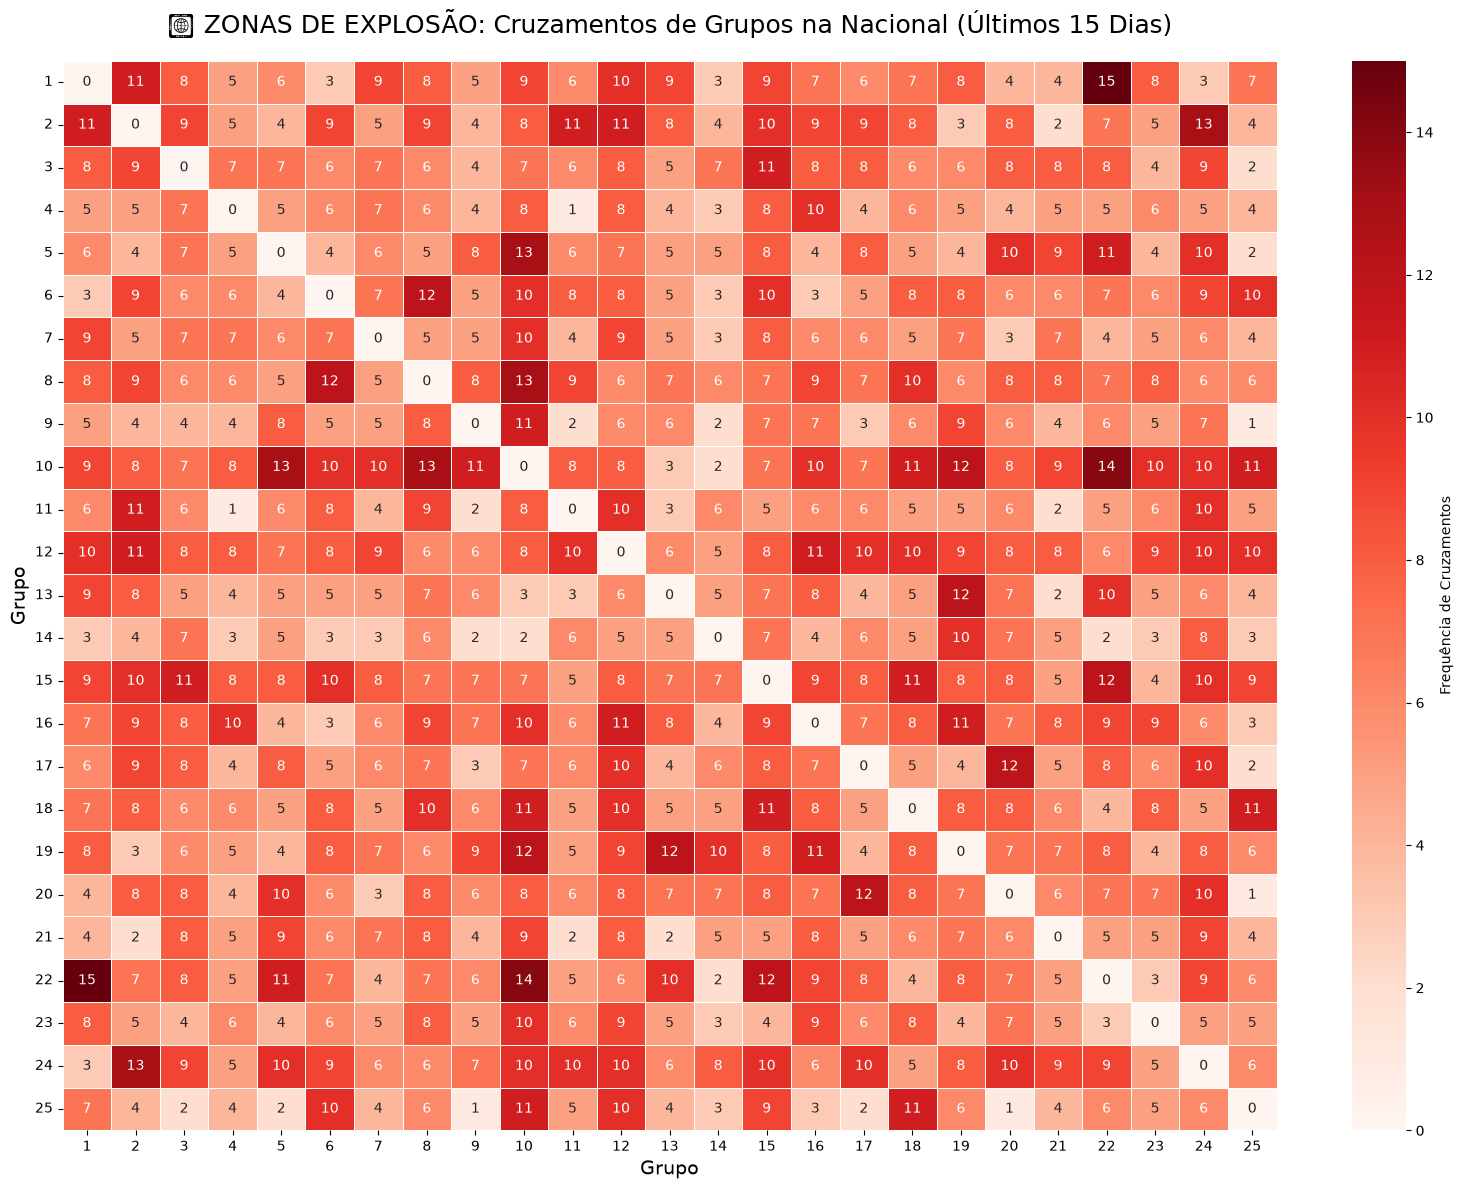

In [27]:
# ==============================================================================
# 🌋 RADAR VISUAL: HEATMAP DE DUQUES DE GRUPO (LOTERIA NACIONAL)
# ==============================================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
from collections import Counter
from sqlalchemy import select
from database import AsyncSessionLocal
from models import ResultadoLoteria

async def gerar_heatmap_nacional():
    print("🔍 Conectando ao NeonDB e extraindo dados para o Heatmap...")
    async with AsyncSessionLocal() as session:
        res = await session.execute(select(ResultadoLoteria))
        df = pd.DataFrame([item.__dict__ for item in res.scalars().all()])
        
    if df.empty:
        print("⚠️ O banco de dados está vazio.")
        return

    # 1. Filtro Exclusivo e Limpeza
    df['data_hora'] = pd.to_datetime(df['data_hora'])
    df_nacional = df[df['no_loteria'] == 'Nacional'].copy()
    
    # 2. Janela de Tempo: Últimos 15 dias (Latência ideal para Duques)
    data_recente = df_nacional['data_hora'].max()
    data_limite = data_recente - pd.Timedelta(days=15)
    df_filtrado = df_nacional[df_nacional['data_hora'] >= data_limite].copy()

    # 3. Extrair o Grupo (se a coluna não estiver preenchida corretamente)
    def calcular_grupo(resultado_str):
        dezena = str(resultado_str).zfill(2)[-2:]
        if not dezena.isdigit(): return None
        dezena_int = int(dezena)
        if dezena_int == 0: return 25
        return ((dezena_int - 1) // 4) + 1

    df_filtrado['grupo_calc'] = df_filtrado['resultado'].apply(calcular_grupo)

    # 4. Agrupar os Grupos por sorteio
    sorteios = df_filtrado.groupby('
    ')['grupo_calc'].unique()
    
    # 5. Criar a Matriz 25x25 zerada
    matriz = pd.DataFrame(0, index=range(1, 26), columns=range(1, 26))

    print("⚙️ Processando a matriz de cruzamentos...")
    # 6. Preencher a Matriz com a frequência dos Duques
    for grupos in sorteios:
        validos = [g for g in grupos if pd.notnull(g)]
        
        # 🚨 CORREÇÃO AQUI: Estava 'validas', mudei para 'validos'
        if len(validos) >= 2:
            pares = list(itertools.combinations(sorted(validos), 2))
            for g1, g2 in pares:
                matriz.at[g1, g2] += 1
                matriz.at[g2, g1] += 1 # Matriz espelhada para visualização completa

    # 7. Renderizar o Gráfico de Calor
    plt.figure(figsize=(16, 12))
    
    # Usamos o cmap 'Reds' para destacar as zonas de explosão
    sns.heatmap(matriz, cmap="Reds", annot=True, fmt="d", linewidths=.5, 
                cbar_kws={'label': 'Frequência de Cruzamentos'})
    
    plt.title('🌋 ZONAS DE EXPLOSÃO: Cruzamentos de Grupos na Nacional (Últimos 15 Dias)', fontsize=18, pad=20)
    plt.xlabel('Grupo', fontsize=14)
    plt.ylabel('Grupo', fontsize=14)
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()

# Dispara a renderização no Jupyter
await gerar_heatmap_nacional()

In [37]:
# ==============================================================================
# 👑 ANÁLISE ESTRATÉGICA: TOP 10 BICHOS POR HORÁRIO E JANELA TEMPORAL (AVANÇADO)
# ==============================================================================
import pandas as pd
from sqlalchemy import select, text
from database import AsyncSessionLocal
from models import ResultadoLoteria 

async def analisar_bichos_por_horario_temporal_avancado():
    print("🔍 Conectando ao NeonDB e extraindo tabelas...")
    async with AsyncSessionLocal() as session:
        # 1. Puxa os resultados da Nacional
        res_resultados = await session.execute(
            select(ResultadoLoteria).where(ResultadoLoteria.no_loteria == 'Nacional')
        )
        df_resultados = pd.DataFrame([item.__dict__ for item in res_resultados.scalars().all()])
        
        # Busca a relação de grupos/bichos direto da tabela de referência
        res_bichos = await session.execute(text("SELECT grupo, bicho FROM tabela_bicho_grupo_dezenas"))
        df_bichos = pd.DataFrame(res_bichos.fetchall(), columns=['grupo_ref', 'bicho_nome'])

    if df_resultados.empty or df_bichos.empty:
        print("⚠️ Dados insuficientes encontrados no banco.")
        return

    # Higienização e cálculo exato do Grupo
    df_resultados['data_hora'] = pd.to_datetime(df_resultados['data_hora'])
    
    def extrair_grupo(resultado_str):
        dezena = str(resultado_str).zfill(2)[-2:]
        if not dezena.isdigit(): return None
        dezena_int = int(dezena)
        if dezena_int == 0: return 25
        return ((dezena_int - 1) // 4) + 1

    df_resultados['grupo_pure'] = df_resultados['resultado'].apply(extrair_grupo)
    
    # Cruzamento com a tabela de bichos do banco
    df_proes = pd.merge(df_resultados, df_bichos, left_on='grupo_pure', right_on='grupo_ref', how='left')
    
    # Definição da data de referência (Último sorteio registrado)
    data_recente = df_proes['data_hora'].max()
    print(f"🕒 Sorteio mais recente do banco: {data_recente.strftime('%d/%m/%Y %H:%M')}")

    # Configuração das Janelas Temporais
    janelas = {
        "Últimos 2 Dias": data_recente - pd.Timedelta(days=2),
        "Últimos 7 Dias": data_recente - pd.Timedelta(days=7),
        "Últimos 15 Dias": data_recente - pd.Timedelta(days=15),
        "Histórico Global": None
    }

    horarios_disponiveis = sorted(df_proes['horario'].dropna().unique())

    # Execução do Motor Multi-Janelas com agregação de colunas extras
    for nome_janela, data_limite in janelas.items():
        print("\n" + "=" * 85)
        print(f" 🔥 ROBUSTEZ TEMPORAL: {nome_janela.upper()} (EXCLUSIVO NACIONAL) 🔥")
        print("=" * 85)
        
        if data_limite is not None:
            df_janela = df_proes[df_proes['data_hora'] >= data_limite]
        else:
            df_janela = df_proes
            
        for hora in horarios_disponiveis:
            df_hora = df_janela[df_janela['horario'] == hora]
            
            if df_hora.empty:
                continue
                
            # Agregação Avançada: Conta as ocorrências e recupera exemplos dos últimos resultados reais
            contagem = df_hora.groupby('bicho_nome').agg(
                Aparições=('bicho_nome', 'count'),
                Ex_Resultados=('resultado', lambda x: ", ".join(x.astype(str).tail(2))), # Traz os 2 últimos outputs reais
                Loteria=('no_loteria', 'first') # Garante a visualização da flag fixa 'Nacional'
            ).reset_index()
            
            # Ordena pelo maior número de aparições
            contagem = contagem.sort_values(by='Aparições', ascending=False).reset_index(drop=True)
            contagem['Posição'] = [f"{i}º" for i in range(1, len(contagem) + 1)]
            
            # 🚨 CORREÇÃO DA ORDEM AQUI: Primeiro renomeia para depois filtrar as colunas
            contagem.rename(columns={'bicho_nome': 'Bicho', 'Ex_Resultados': 'Últimos Resultados'}, inplace=True)
            top_10_hora = contagem.head(10)[['Posição', 'Bicho', 'Aparições', 'Últimos Resultados', 'Loteria']]
            
            print(f"\n⏰ HORÁRIO: {hora} | Janela: {nome_janela} (Amostras no Turno: {len(df_hora)})")
            print("-" * 65)
            display(top_10_hora.style.hide(axis="index"))

# Executa o painel completo atualizado no Jupyter
await analisar_bichos_por_horario_temporal_avancado()

🔍 Conectando ao NeonDB e extraindo tabelas...
🕒 Sorteio mais recente do banco: 17/07/2026 10:00

 🔥 ROBUSTEZ TEMPORAL: ÚLTIMOS 2 DIAS (EXCLUSIVO NACIONAL) 🔥

⏰ HORÁRIO: 02:00 | Janela: Últimos 2 Dias (Amostras no Turno: 14)
-----------------------------------------------------------------


Posição,Bicho,Aparições,Últimos Resultados,Loteria
1º,ÁGUIA,2,"3506, 9208",Nacional
2º,VEADO,2,"0096, 4894",Nacional
3º,CABRA,1,2921,Nacional
4º,CACHORRO,1,2417,Nacional
5º,COELHO,1,2140,Nacional
6º,CAVALO,1,4544,Nacional
7º,ELEFANTE,1,5047,Nacional
8º,JACARÉ,1,9858,Nacional
9º,PAVÃO,1,0273,Nacional
10º,MACACO,1,1666,Nacional



⏰ HORÁRIO: 08:00 | Janela: Últimos 2 Dias (Amostras no Turno: 14)
-----------------------------------------------------------------


Posição,Bicho,Aparições,Últimos Resultados,Loteria
1º,VACA,3,"3897, 5399",Nacional
2º,BORBOLETA,1,9516,Nacional
3º,CACHORRO,1,0817,Nacional
4º,CABRA,1,7123,Nacional
5º,CAVALO,1,1842,Nacional
6º,COELHO,1,4439,Nacional
7º,MACACO,1,1466,Nacional
8º,ELEFANTE,1,0947,Nacional
9º,PAVÃO,1,4673,Nacional
10º,TIGRE,1,2487,Nacional



⏰ HORÁRIO: 10:00 | Janela: Últimos 2 Dias (Amostras no Turno: 21)
-----------------------------------------------------------------


...

Posição,Bicho,Aparições,Últimos Resultados,Loteria
1º,PERU,26,"1078, 4780",Nacional
2º,BURRO,25,"9709, 0109",Nacional
3º,CAMELO,24,"3432, 8031",Nacional
4º,TOURO,23,"2381, 0084",Nacional
5º,CABRA,21,"0122, 5022",Nacional
6º,JACARÉ,21,"6760, 9357",Nacional
7º,ELEFANTE,20,"6447, 1046",Nacional
8º,AVESTRUZ,19,"4301, 5804",Nacional
9º,BORBOLETA,19,"8516, 6815",Nacional
10º,MACACO,19,"1265, 3367",Nacional



⏰ HORÁRIO: 21:00 | Janela: Histórico Global (Amostras no Turno: 420)
-----------------------------------------------------------------


Posição,Bicho,Aparições,Últimos Resultados,Loteria
1º,ÁGUIA,27,"1908, 7207",Nacional
2º,BORBOLETA,24,"1116, 0915",Nacional
3º,COELHO,21,"5138, 9137",Nacional
4º,VACA,21,"0898, 7600",Nacional
5º,AVESTRUZ,19,"2401, 5102",Nacional
6º,GALO,19,"2751, 1549",Nacional
7º,TOURO,19,"0383, 3682",Nacional
8º,MACACO,18,"7468, 5368",Nacional
9º,CABRA,18,"2124, 0322",Nacional
10º,TIGRE,17,"0487, 0086",Nacional



⏰ HORÁRIO: 23:00 | Janela: Histórico Global (Amostras no Turno: 420)
-----------------------------------------------------------------


Posição,Bicho,Aparições,Últimos Resultados,Loteria
1º,GALO,25,"6952, 1051",Nacional
2º,MACACO,23,"6865, 2268",Nacional
3º,PERU,23,"8679, 2677",Nacional
4º,CAMELO,22,"5931, 6029",Nacional
5º,PORCO,21,"0169, 3970",Nacional
6º,VEADO,20,"5194, 0293",Nacional
7º,BORBOLETA,18,"0414, 2014",Nacional
8º,LEÃO,18,"8464, 9163",Nacional
9º,PAVÃO,18,"2976, 8575",Nacional
10º,JACARÉ,17,"1257, 0058",Nacional


In [42]:
# ==============================================================================
# 🎯 LATÊNCIA CORRIGIDA: APENAS DEZENAS ALTAS (PRESSÃO REAL NA NACIONAL)
# ==============================================================================
import pandas as pd
from sqlalchemy import select, text
from database import AsyncSessionLocal
from models import ResultadoLoteria

async def calcular_atrasados_reais_nacional():
    async with AsyncSessionLocal() as session:
        res_resultados = await session.execute(
            select(ResultadoLoteria)
            .where(ResultadoLoteria.no_loteria == 'Nacional')
            .order_by(ResultadoLoteria.data_hora.asc())
        )
        df_resultados = pd.DataFrame([item.__dict__ for item in res_resultados.scalars().all()])
        
        res_bichos = await session.execute(text("SELECT grupo, bicho FROM tabela_bicho_grupo_dezenas"))
        df_bichos = pd.DataFrame(res_bichos.fetchall(), columns=['grupo_num', 'bicho_nome'])

    if df_resultados.empty or df_bichos.empty:
        return

    df_resultados['data_hora'] = pd.to_datetime(df_resultados['data_hora'])
    
    # 🚨 AQUI ESTÁ A CORREÇÃO: Analisamos apenas dezenas que a Nacional realmente solta (27 a 99)
    dezenas_altas = [str(i).zfill(2) for i in range(27, 100)]
    
    def mapear_bicho_da_dezena(dezena_str):
        dez_int = int(dezena_str)
        grupo_calc = 25 if dez_int == 0 else ((dez_int - 1) // 4) + 1
        nome_bicho = df_bichos[df_bichos['grupo_num'] == grupo_calc]['bicho_nome'].values
        return f"{nome_bicho[0]} (Gr. {grupo_calc})" if len(nome_bicho) > 0 else "Desconhecido"

    # Foco estrito no horário das 12:00 que vai correr agora!
    df_hora = df_resultados[df_resultados['horario'] == '12:00'].copy()
    df_cabeca = df_hora[df_hora['premio'] == 1].copy()
    df_cabeca['dezena_pure'] = df_cabeca['resultado'].astype(str).str.zfill(2).str[-2:]
    
    total_sorteios_turno = len(df_hora)
    dados_atraso = []
    
    for dezena in dezenas_altas:
        sorteios_da_dezena = df_cabeca[df_cabeca['dezena_pure'] == dezena]
        
        if sorted(sorteios_da_dezena.index):
            ultimo_index_dezena = sorteios_da_dezena.index[-1]
            atraso_sorteios = len(df_hora[df_hora.index > ultimo_index_dezena])
            ultimo_sorteio_data = sorteios_da_dezena['data_hora'].dt.strftime('%d/%m/%Y').values[-1]
            
            dados_atraso.append({
                "Dezena": dezena,
                "Bicho Coberto": mapear_bicho_da_dezena(dezena),
                "Atraso Reais (Sorteios)": atraso_sorteios,
                "Última Vez na Cabeça": ultimo_sorteio_data
            })
        
    df_atrasadas = pd.DataFrame(dados_atraso)
    df_atrasadas = df_atrasadas.sort_values(by="Atraso Reais (Sorteios)", ascending=False).reset_index(drop=True)
    df_atrasadas['Posição'] = [f"{i}º" for i in range(1, len(df_atrasadas) + 1)]
    
    print("\n" + "=" * 75)
    print(" 🚨 ALVOS REAIS PARA ÀS 12:00: DEZENAS ALTAS MAIS SUFOCADAS 🚨")
    print("=" * 75)
    display(df_atrasadas.head(5)[['Posição', 'Dezena', 'Bicho Coberto', 'Atraso Reais (Sorteios)', 'Última Vez na Cabeça']].style.hide(axis="index"))

await calcular_atrasados_reais_nacional()


 🚨 ALVOS REAIS PARA ÀS 12:00: DEZENAS ALTAS MAIS SUFOCADAS 🚨


Posição,Dezena,Bicho Coberto,Atraso Reais (Sorteios),Última Vez na Cabeça
1º,55,GATO (Gr. 14),426,18/05/2026
2º,36,COBRA (Gr. 9),402,21/05/2026
3º,97,VACA (Gr. 25),391,23/05/2026
4º,70,PORCO (Gr. 18),378,24/05/2026
5º,81,TOURO (Gr. 21),364,26/05/2026


In [45]:
# ==============================================================================
# 🛰️ RECALCULANDO LATÊNCIA: ALVOS CRÍTICOS PARA ÀS 15:00 (DEZENAS ALTAS)
# ==============================================================================
import pandas as pd
from sqlalchemy import select, text
from database import AsyncSessionLocal
from models import ResultadoLoteria

async def recalcular_pressao_15h():
    async with AsyncSessionLocal() as session:
        res_resultados = await session.execute(
            select(ResultadoLoteria)
            .where(ResultadoLoteria.no_loteria == 'Nacional')
            .order_by(ResultadoLoteria.data_hora.asc())
        )
        df_resultados = pd.DataFrame([item.__dict__ for item in res_resultados.scalars().all()])
        
        res_bichos = await session.execute(text("SELECT grupo, bicho FROM tabela_bicho_grupo_dezenas"))
        df_bichos = pd.DataFrame(res_bichos.fetchall(), columns=['grupo_num', 'bicho_nome'])

    if df_resultados.empty or df_bichos.empty:
        return

    df_resultados['data_hora'] = pd.to_datetime(df_resultados['data_hora'])
    dezenas_altas = [str(i).zfill(2) for i in range(27, 100)]
    
    def mapear_bicho_da_dezena(dezena_str):
        dez_int = int(dezena_str)
        grupo_calc = 25 if dez_int == 0 else ((dez_int - 1) // 4) + 1
        nome_bicho = df_bichos[df_bichos['grupo_num'] == grupo_calc]['bicho_nome'].values
        return f"{nome_bicho[0]} (Gr. {grupo_calc})" if len(nome_bicho) > 0 else "Desconhecido"

    # Isolando estritamente o corte das 15:00
    df_hora = df_resultados[df_resultados['horario'] == '15:00'].copy()
    df_cabeca = df_hora[df_hora['premio'] == 1].copy()
    df_cabeca['dezena_pure'] = df_cabeca['resultado'].astype(str).str.zfill(2).str[-2:]
    
    total_sorteios_turno = len(df_hora)
    dados_atraso = []
    
    for dezena in dezenas_altas:
        sorteios_da_dezena = df_cabeca[df_cabeca['dezena_pure'] == dezena]
        if sorted(sorteios_da_dezena.index):
            ultimo_index_dezena = sorteios_da_dezena.index[-1]
            atraso_sorteios = len(df_hora[df_hora.index > ultimo_index_dezena])
            ultimo_sorteio_data = sorteios_da_dezena['data_hora'].dt.strftime('%d/%m/%Y').values[-1]
            
            dados_atraso.append({
                "Dezena": dezena,
                "Bicho Coberto": mapear_bicho_da_dezena(dezena),
                "Atraso (Sorteios)": atraso_sorteios,
                "Última Vez na Cabeça": ultimo_sorteio_data
            })
        
    df_atrasadas = pd.DataFrame(dados_atraso)
    df_atrasadas = df_atrasadas.sort_values(by="Atraso (Sorteios)", ascending=False).reset_index(drop=True)
    df_atrasadas['Posição'] = [f"{i}º" for i in range(1, len(df_atrasadas) + 1)]
    
    print("\n" + "=" * 75)
    print(" 🚨 ALVOS DE LATÊNCIA MÁXIMA PARA ÀS 15:00 🚨")
    print("=" * 75)
    display(df_atrasadas.head(5)[['Posição', 'Dezena', 'Bicho Coberto', 'Atraso (Sorteios)', 'Última Vez na Cabeça']].style.hide(axis="index"))

await recalcular_pressao_15h()


 🚨 ALVOS DE LATÊNCIA MÁXIMA PARA ÀS 15:00 🚨


Posição,Dezena,Bicho Coberto,Atraso (Sorteios),Última Vez na Cabeça
1º,93,VEADO (Gr. 24),413,18/05/2026
2º,77,PERU (Gr. 20),408,19/05/2026
3º,50,GALO (Gr. 13),392,21/05/2026
4º,90,URSO (Gr. 23),391,22/05/2026
5º,76,PAVÃO (Gr. 19),378,23/05/2026
